# Comparison of different models for demand forecasting

In [23]:
import pandas as pd
import json
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from metrics.wape import wape
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer, mean_absolute_error
from experiments.baseline import baseline_metrics
from experiments.report import regression_report
from experiments.error_analysis import error_analysis, error_by_segment
import optuna
import numpy as np
import warnings
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.compose import TransformedTargetRegressor
import ast
import shap
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Load the transformed datasets
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()  # Convert to Series
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()  # Convert to Series

In [3]:
# Use selected features for modeling
with open('../configs/linear_features.json', 'r') as f:
    linear_features = json.load(f)

with open('../configs/tree_features.json', 'r') as f:
    tree_features = json.load(f)

## Baselines

In [12]:
# Evaluate baseline metrics
X_test_baseline = pd.read_csv('../data/before_preprocessor/X_test.csv')
baseline_metrics_df = baseline_metrics(X_test_baseline, y_test)
baseline_metrics_df

,Value,RMSE,MAE,WAPE
4,rolling_mean_2,396.407832,214.428571,0.108547
5,rolling_mean_4,409.242747,219.968750,0.111351
0,lag_1,366.134343,221.928571,0.112344
3,lag_4,436.734248,245.839286,0.124447
2,lag_3,473.909839,249.964286,0.126536
1,lag_2,459.875488,254.607143,0.128886


In [44]:
# Time series cross-validation setup
tss = TimeSeriesSplit(n_splits=3)

In [5]:
# Define WAPE scorer for Optuna
wape_scorer = make_scorer(wape, greater_is_better=False)

## Linear regression

In [12]:
# Train and evaluate Linear Regression with selected tree features
lr = LinearRegression()
lr.fit(X_train[tree_features], y_train)
lr_preds = lr.predict(X_test[tree_features])
lr_report = regression_report(y_test, lr_preds,name='Linear Regression with tree features')
lr_report

,Model,Hyperparameters,MAE,WAPE,RMSE,R2 Score
0,Linear Regression with tree features,{},394.1868,0.199543,567.717767,0.87991


## Lasso

In [ ]:
def lasso_objective(trial):
    alpha = trial.suggest_float('alpha', 0.0001, 100.0, log=True)
    iterations = trial.suggest_int('max_iter', 1000, 10000)
    lasso = Lasso(alpha=alpha, max_iter=iterations, random_state=42)
    tr = TransformedTargetRegressor(regressor=lasso, func=np.log1p, inverse_func=np.expm1)
    scores = cross_val_score(lasso, X_train, y_train, cv=tss, scoring=wape_scorer)
    return -scores.mean()
lasso_study = optuna.create_study(direction='minimize')
lasso_study.optimize(lasso_objective, n_trials=50,show_progress_bar=True)

In [30]:
lasso = Lasso(**lasso_study.best_params, random_state=42)
lasso.fit(X_train, y_train)
lasso_preds = lasso.predict(X_test)
lasso_report = regression_report(y_test, lasso_preds,name='Lasso Regression with all features', hyperparams=lasso_study.best_params)
lasso_report

,Model,Hyperparameters,MAE,WAPE,RMSE,R2 Score
0,Lasso Regression with all features,"{'alpha': 26.085098226616264, 'max_iter': 6790}",242.579971,0.122798,462.369859,0.920344


## Ridge

In [ ]:
def ridge_objective(trial):
    alpha = trial.suggest_float('alpha', 0.0001, 100.0, log=True)
    iterations = trial.suggest_int('max_iter', 1000, 10000)
    ridge = Ridge(alpha=alpha, max_iter=iterations, random_state=42)
    tr = TransformedTargetRegressor(regressor=ridge, func=np.log1p, inverse_func=np.expm1)
    scores = cross_val_score(ridge, X_train, y_train, cv=tss, scoring=wape_scorer)
    return -scores.mean()
ridge_study = optuna.create_study(direction='minimize')
ridge_study.optimize(ridge_objective, n_trials=50,show_progress_bar=True)

In [42]:
ridge = Ridge(**ridge_study.best_params, random_state=42)
ridge.fit(X_train, y_train)
ridge_preds = ridge.predict(X_test)
ridge_report = regression_report(y_test, ridge_preds,name='Ridge Regression with all features', hyperparams=ridge_study.best_params)
ridge_report

,Model,Hyperparameters,MAE,WAPE,RMSE,R2 Score
0,Ridge Regression with all features,"{'alpha': 99.93000634340225, 'max_iter': 8125}",256.300819,0.129743,479.970597,0.914164


## Random Forest

In [ ]:
def random_forest_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.1),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'max_samples': trial.suggest_float('max_samples', 0.5, 1.0),
        'criterion': trial.suggest_categorical('criterion', ['squared_error', 'absolute_error', 'poisson']),
        'n_jobs': -1
    }
    rf = RandomForestRegressor(**params, random_state=42)
    tr = TransformedTargetRegressor(
        regressor=rf,
        func=np.log1p,
        inverse_func=np.expm1
    )
    scores = cross_val_score(rf, X_train, y_train, cv=tss, scoring=wape_scorer, n_jobs=-1)
    return -scores.mean()
rf_study = optuna.create_study(direction='minimize')
rf_study.optimize(random_forest_objective, n_trials=50,show_progress_bar=True)

In [55]:
rf = RandomForestRegressor(**rf_study.best_params, random_state=42)
rf.fit(X_train,y_train)
rf_preds = rf.predict(X_test)
rf_report = regression_report(y_test, rf_preds,name='Random Forest with all features', hyperparams=rf_study.best_params)
rf_report

,Model,Hyperparameters,MAE,WAPE,RMSE,R2 Score
0,Random Forest with all features,"{'n_estimators': 726, 'max_depth': 11, 'min_sa...",229.947686,0.116403,416.726124,0.935294


## Catboost

In [ ]:
def catboost_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 2000),
        'depth': trial.suggest_int('depth', 2, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-5, 100, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_strength': trial.suggest_float('random_strength', 0.0, 1.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'loss_function': trial.suggest_categorical('loss_function', ['RMSE', 'MAE']),
        'thread_count': -1,
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.2, 1.0),
        'subsample': trial.suggest_float('subsample', 0.2, 1.0),
    }

    cat = CatBoostRegressor(**params, random_state=42, verbose=0)
    tr = TransformedTargetRegressor(
        regressor=cat,
        func=np.log1p,
        inverse_func=np.expm1
    )
    scores = cross_val_score(tr, X_train, y_train, cv=tss, scoring=wape_scorer, n_jobs=-1)
    return -scores.mean()
cat_study = optuna.create_study(direction='minimize')
cat_study.optimize(catboost_objective, n_trials=50,show_progress_bar=True)

In [67]:
cb = CatBoostRegressor(**cat_study.best_params, random_state=42, verbose=0)
cb.fit(X_train, np.log1p(y_train))
cb_preds = cb.predict(X_test)
cb_preds = np.expm1(cb_preds)  # Inverse of log1p
cb_report = regression_report(y_test, cb_preds,name='CatBoost with all features (logged)', hyperparams=cat_study.best_params)
cb_report

,Model,Hyperparameters,MAE,WAPE,RMSE,R2 Score
0,CatBoost with all features (logged),"{'iterations': 1662, 'depth': 5, 'learning_rat...",241.26421,0.122131,423.52797,0.933165


## LightGBM

In [ ]:
def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'max_depth': trial.suggest_int('max_depth', 2, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 250),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 100, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 100, log=True),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.3, 1.0),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.3, 1.0),
        'n_jobs': -1,
    }
    lgbm = LGBMRegressor(**params, random_state=42)
    tr = TransformedTargetRegressor(
        regressor=lgbm,
        func=np.log1p,
        inverse_func=np.expm1
    )
    scores = cross_val_score(lgbm, X_train, y_train, cv=tss, scoring=wape_scorer, n_jobs=-1)
    return -scores.mean()
lgbm_study = optuna.create_study(direction='minimize')
lgbm_study.optimize(lgbm_objective, n_trials=50,show_progress_bar=True)

In [ ]:
lgbm = LGBMRegressor(**lgbm_study.best_params, random_state=42)
lgbm.fit(X_train,y_train)
lgbm_preds = lgbm.predict(X_test)
lgbm_report = regression_report(y_test, lgbm_preds,name='LightGBM with all features', hyperparams=lgbm_study.best_params)
lgbm_report

## XGBoost

In [ ]:
def xgboost_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'max_depth': trial.suggest_int('max_depth', 2, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.3, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'alpha': trial.suggest_float('alpha', 1e-5, 100, log=True),
        'lambda': trial.suggest_float('lambda', 1e-5, 100, log=True),
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-5, 100, log=True),
        'n_jobs': -1,
    }
    xgb = XGBRegressor(**params, random_state=42)
    tr = TransformedTargetRegressor(
        regressor=xgb,
        func=np.log1p,
        inverse_func=np.expm1
    )
    scores = cross_val_score(xgb, X_train, y_train, cv=tss, scoring=wape_scorer, n_jobs=-1)
    return -scores.mean()
xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgboost_objective, n_trials=50,show_progress_bar=True)

In [91]:
xgb = XGBRegressor(**xgb_study.best_params, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_report = regression_report(y_test, xgb_preds,name='XGBoost with all features', hyperparams=xgb_study.best_params)
xgb_report

,Model,Hyperparameters,MAE,WAPE,RMSE,R2 Score
0,XGBoost with all features,"{'n_estimators': 1614, 'max_depth': 4, 'learni...",247.130539,0.125101,458.842412,0.921555


## Results

In [5]:
# Compile all results into a single DataFrame and calculate improvement over baseline
results = pd.read_csv('../results/regression_report.csv')
best_baseline = 0.1086
results['improvement_over_baseline'] = (best_baseline - results["WAPE"]) / best_baseline * 100
results['improvement_over_baseline'] = results['improvement_over_baseline'].map('{:.2f}%'.format)
results.sort_values('WAPE')

,Model,Hyperparameters,MAE,WAPE,RMSE,R2 Score,improvement_over_baseline
36,LightGBM with linear features,"{'n_estimators': 936, 'max_depth': 5, 'learnin...",221.252199,0.112001,386.857883,0.944237,-3.13%
10,Lasso Regression with tree features,"{'alpha': 9.998617213392928, 'max_iter': 5765}",221.609137,0.112182,406.303450,0.938491,-3.30%
21,Random Forest with tree features (logged),"{'n_estimators': 636, 'max_depth': 8, 'min_sam...",222.056399,0.112408,425.771091,0.932455,-3.51%
13,Lasso Regression with tree features,"{'alpha': 11.514164639963314, 'max_iter': 2810}",222.575063,0.112671,410.744822,0.937139,-3.75%
22,Random Forest with all features (logged),"{'n_estimators': 994, 'max_depth': 7, 'min_sam...",225.360376,0.114081,403.224753,0.939419,-5.05%
27,CatBoost with all features,"{'iterations': 915, 'depth': 2, 'learning_rate...",227.525416,0.115177,401.814331,0.939842,-6.06%
43,XGBoost with tree features,"{'n_estimators': 1964, 'max_depth': 4, 'learni...",227.937790,0.115385,408.178940,0.937921,-6.25%
23,Random Forest with linear features (logged),"{'n_estimators': 756, 'max_depth': 19, 'min_sa...",228.061959,0.115448,438.353059,0.928404,-6.31%
25,Random Forest with tree features,"{'n_estimators': 563, 'max_depth': 8, 'min_sam...",228.612062,0.115727,411.337913,0.936957,-6.56%
19,Ridge Regression with tree features,"{'alpha': 20.153286150085993, 'max_iter': 8127}",229.252660,0.116051,405.117395,0.938849,-6.86%


In [6]:
# Best parameters for the best model
best_params = results[results['Model'] == 'LightGBM with linear features']['Hyperparameters'].values[0]
best_params = ast.literal_eval(best_params)
best_params

{'n_estimators': 936,
 'max_depth': 5,
 'learning_rate': 0.14701188424794637,
 'num_leaves': 152,
 'min_child_samples': 5,
 'reg_alpha': 0.47063038185334827,
 'reg_lambda': 0.5945956524559243,
 'bagging_fraction': 0.9204010492639254,
 'feature_fraction': 0.9539791641630462}

In [ ]:
# Best model
lgbm = LGBMRegressor(**best_params, random_state=42)
lgbm.fit(X_train[linear_features], y_train)
lgbm_preds = lgbm.predict(X_test[linear_features])
print(f'WAPE: {wape(y_test, lgbm_preds):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, lgbm_preds)):.4f}')
print(f'R2 Score: {r2_score(y_test, lgbm_preds):.4f}')
print(f'MAE: {mean_absolute_error(y_test, lgbm_preds):.4f}')

In [13]:
# Error analysis
errors_df = error_analysis(X_test_baseline, y_test, lgbm_preds)
errors_df

,month,specialization,fact,prediction,abs_error,perc_error,error_type
23,12,Data Analyst,2218,3690,1472,0.663661,Overprediction
39,12,Data Scientist,2126,3414,1288,0.605833,Overprediction
31,12,Data Engineer,2694,3933,1239,0.459911,Overprediction
22,12,Data Analyst,3558,4246,688,0.193367,Overprediction
27,12,Data Engineer,3932,4501,569,0.144710,Overprediction
30,12,Data Engineer,3702,4254,552,0.149109,Overprediction
26,11,Data Engineer,4704,4159,545,0.115859,Underprediction
36,12,Data Scientist,3966,3434,532,0.134140,Underprediction
35,12,Data Scientist,3678,4133,455,0.123709,Overprediction
19,12,Data Analyst,3655,4044,389,0.106430,Overprediction


In [14]:
# Analyze errors by specialization segment
segment_errors = error_by_segment(errors_df, 'specialization')
segment_errors

,specialization,mean_abs_error,mean_perc_error
2,Data Analyst,430.625,0.147738
4,Data Scientist,426.125,0.145579
3,Data Engineer,424.000,0.123144
0,Business Analyst,109.875,0.134458
6,Software Engineer,105.125,0.119520
1,Cloud Engineer,30.750,0.112044
5,Machine Learning Engineer,22.250,0.080041


In [15]:
# Analyze errors by month segment
segment_errors = error_by_segment(errors_df, 'month')
segment_errors

,month,mean_abs_error,mean_perc_error
1,12,285.200000,0.164590
0,11,114.666667,0.054263


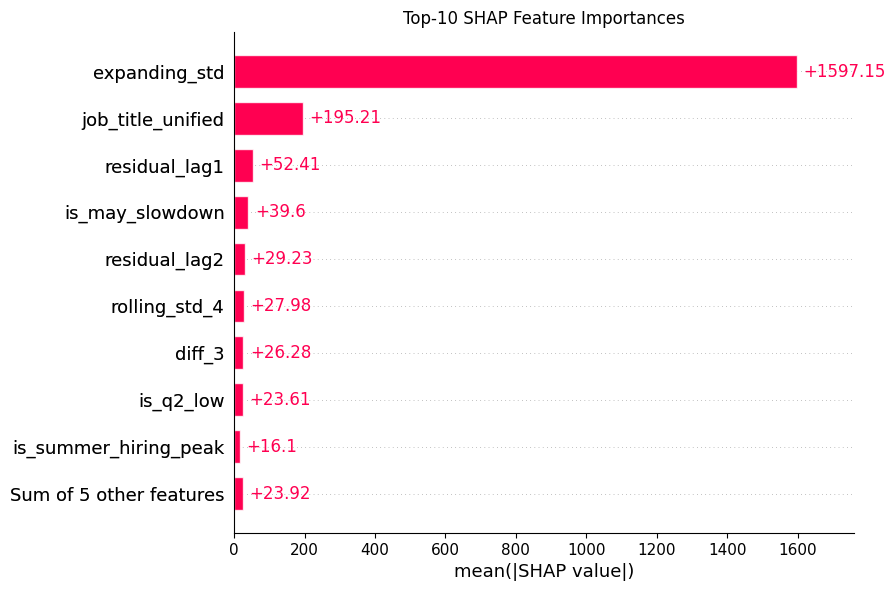

In [24]:
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test[linear_features])
plt.figure(figsize=(10, 6))
plt.title("Top-10 SHAP Feature Importances")
shap.plots.bar(shap_values, max_display=10, show=True)

[LightGBM] [Warning] feature_fraction is set=0.9539791641630462, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9539791641630462
[LightGBM] [Warning] bagging_fraction is set=0.9204010492639254, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9204010492639254


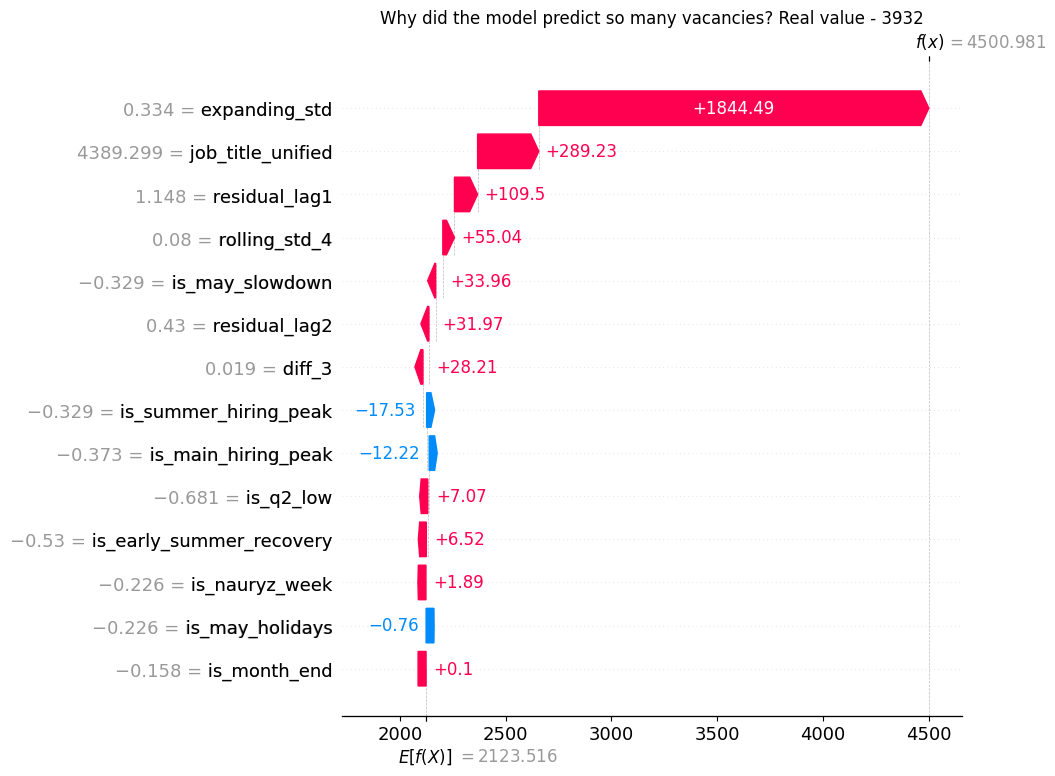

In [27]:
max_demand_idx = np.argmax(lgbm.predict(X_test[linear_features]))
real_value = y_test.iloc[max_demand_idx]
plt.figure(figsize=(10, 6))
plt.title(f"Why did the model predict so many vacancies? Real value - {real_value}")
shap.plots.waterfall(shap_values[max_demand_idx], max_display=15, show=True)